# Étude comparative des méthodes d'optimisation — HEAT-COND

Sept études sur les trois optimiseurs : **Differential Evolution (DE)**,
**Nelder-Mead (NM)**, **Basinhopping (BH)**.

| # | Étude | Question | Mesh | Coût approx. |
|---|---|---|---|---|
| 1 | Comparaison à budget équivalent | Quelle méthode est la plus efficiente ? | 50 | 3-5 min |
| 2 | Impact du maillage | $J^\star(\text{mesh})$ converge-t-il ? | 15-60 | 5-10 min |
| 3 | Sensibilité au point initial (NM, BH) | Méthode locale fiable ? | 25 | 1-2 min |
| 4 | Sensibilité à la graine (DE, BH) | Variabilité aléatoire problématique ? | 25 | 1-2 min |
| 5 | Hyperparamètres DE (popsize, mutation, strategy) | Quel réglage optimal ? *Moyenne sur 3 graines* | 25 | 5-7 min |
| 6 | Hyperparamètres BH (stepsize, T) | Quels effets ? *Moyenne sur 3 graines* | 25 | 3-4 min |
| 7 | Designs optimaux et champs $T$ | Convergence vers le même optimum physique ? | 50 | <1 min |

**Pré-requis** : FreeFEM++ installé, `.env` configuré, exécuter depuis `heat_opti_final/`.
Les prints par évaluation et les barres tqdm sont désactivés via `optimization.VERBOSE = False`.
Toutes les figures et CSV vont dans `results_compare/`.


## Configuration


In [1]:
import os, sys, time
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src' / 'optimization.py').exists():
    candidate = ROOT / 'heat_opti_final'
    if (candidate / 'src' / 'optimization.py').exists():
        os.chdir(candidate); ROOT = candidate
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.freefem_interface import (
    ensure_mesh, run_solver, read_temperature_field, read_freefem_mesh,
)
import src.optimization as opt
from src.optimization import (
    run_differential_evolution, run_nelder_mead, run_basinhopping,
    reset_optimization,
)
from src.visualization import draw_temperature, draw_convergence_comparison

# Silence les prints et les barres tqdm de src.optimization
opt.VERBOSE = False

# Formatage des DataFrames sans dépendre de jinja2 (pas de Styler)
pd.options.display.float_format = '{:.5f}'.format

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BOUNDS = [(0.1, 1.0)] * 5 + [(0.01, 1.0)]
PARAM_LABELS = ['k1', 'k2', 'k3', 'k4', 'k5', 'Bi']
MESH_REF = 50
MESH_CHEAP = 25

# Études 5 & 6 : nombre de graines pour moyenner les hyperparamètres
N_SEEDS_HP = 3
SEEDS_HP = list(range(N_SEEDS_HP))

NB_DIR = ROOT / 'results_compare'
NB_DIR.mkdir(exist_ok=True)
print('Working dir :', ROOT)
print('Sorties NB  :', NB_DIR)
print('N_SEEDS_HP  :', N_SEEDS_HP)


Working dir : /Users/zhulaurent/Documents/Claude/Projects/Project (Heat Conduction) - ONA/Optimisation-Heat-Conduction/heat_opti_final
Sorties NB  : /Users/zhulaurent/Documents/Claude/Projects/Project (Heat Conduction) - ONA/Optimisation-Heat-Conduction/heat_opti_final/results_compare
N_SEEDS_HP  : 3


## Design initial $J_0$


In [2]:
ensure_mesh(MESH_REF)
x0_ref = [0.5] * 5 + [0.5]
t0 = time.time()
J0 = run_solver(x0_ref, mesh_size=MESH_REF)
print(f'J0 = {J0:.6f}  ({time.time()-t0:.2f} s pour un solve à mesh={MESH_REF})')


J0 = 0.076811  (0.38 s pour un solve à mesh=50)


## Étude 1 — Comparaison des 3 méthodes à budget équivalent

Mesh = 50. Budgets choisis pour des temps comparables. `seed=42` pour DE et BH.


In [3]:
results = {}

t = time.time()
results['DE'] = run_differential_evolution(
    BOUNDS, maxiter=10, popsize=4, mesh_size=MESH_REF, seed=42,
)
print(f'DE  : J* = {results["DE"]["best_J"]:.6f}  '
      f'n_eval = {results["DE"]["n_eval"]:>4d}  t = {time.time()-t:.1f}s')
reset_optimization()

t = time.time()
results['NM'] = run_nelder_mead(BOUNDS, maxiter=100, mesh_size=MESH_REF)
print(f'NM  : J* = {results["NM"]["best_J"]:.6f}  '
      f'n_eval = {results["NM"]["n_eval"]:>4d}  t = {time.time()-t:.1f}s')
reset_optimization()

t = time.time()
results['BH'] = run_basinhopping(BOUNDS, niter=10, mesh_size=MESH_REF, seed=42)
print(f'BH  : J* = {results["BH"]["best_J"]:.6f}  '
      f'n_eval = {results["BH"]["n_eval"]:>4d}  t = {time.time()-t:.1f}s')
reset_optimization()


KeyboardInterrupt: 

### Tableau de synthèse


In [ ]:
rows = []
for r in results.values():
    rows.append({
        'Méthode'          : r['method'],
        'J*'               : r['best_J'],
        'Gain vs J0'       : r['best_J'] - J0,
        'Gain relatif (%)' : 100 * (r['best_J'] - J0) / abs(J0),
        'n_eval'           : r['n_eval'],
        'Temps (s)'        : r['time'],
        'Temps/éval (s)'   : r['time'] / max(1, r['n_eval']),
        'Convergé'         : bool(r['success']),
    })
df_summary = pd.DataFrame(rows).sort_values('J*', ascending=False).reset_index(drop=True)
df_summary.to_csv(NB_DIR / 'etude1_summary.csv', index=False)
df_summary


### Convergence comparée


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
draw_convergence_comparison(ax, {r['method']: r['history'] for r in results.values()})
ax.axhline(J0, color='gray', ls='--', lw=1.2, label=f'J0 = {J0:.4f}')
ax.legend()
fig.tight_layout()
fig.savefig(NB_DIR / 'etude1_convergence.png', dpi=200, bbox_inches='tight')
plt.show()


### Pareto $J^\star$ vs temps


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10.colors
for i, r in enumerate(results.values()):
    ax.scatter(r['time'], r['best_J'], s=180, color=colors[i],
               label=r['method'], edgecolors='black', linewidths=1)
    ax.annotate(r['method'], (r['time'], r['best_J']),
                xytext=(8, 6), textcoords='offset points', fontsize=10)
ax.axhline(J0, color='gray', ls='--', lw=1, label=f'J0 = {J0:.4f}')
ax.set_xlabel('Temps de calcul (s)')
ax.set_ylabel('Meilleur J*')
ax.set_title('Pareto : qualité finale vs coût')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(NB_DIR / 'etude1_pareto.png', dpi=200, bbox_inches='tight')
plt.show()


## Étude 2 — Impact de la résolution du maillage

On lance les 3 méthodes (budgets fixés) sur mesh ∈ {15, 25, 40, 60} et on regarde
$J^\star$, le temps total, et le temps par évaluation.

⚠️ Cellule longue (~5-10 min).


In [ ]:
MESH_SIZES_STUDY = [15, 25, 40, 60]
method_runs = [
    ('DE', lambda ms: run_differential_evolution(BOUNDS, maxiter=6, popsize=4, mesh_size=ms, seed=42)),
    ('NM', lambda ms: run_nelder_mead(BOUNDS, maxiter=70, mesh_size=ms)),
    ('BH', lambda ms: run_basinhopping(BOUNDS, niter=6, mesh_size=ms, seed=42)),
]

mesh_results = []
for ms in MESH_SIZES_STUDY:
    ensure_mesh(ms)
    for key, runner in method_runs:
        r = runner(ms)
        mesh_results.append({
            'method': r['method'], 'mesh_size': ms,
            'J*': r['best_J'], 'n_eval': r['n_eval'], 'time': r['time'],
        })
        reset_optimization()
        print(f'  {key} @ mesh={ms:3d} : J* = {r["best_J"]:.5f}, n_eval = {r["n_eval"]:3d}, t = {r["time"]:.1f}s')

df_mesh = pd.DataFrame(mesh_results)
df_mesh.to_csv(NB_DIR / 'etude2_mesh.csv', index=False)
df_mesh.pivot(index='mesh_size', columns='method', values='J*')


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for m in df_mesh['method'].unique():
    sub = df_mesh[df_mesh['method'] == m].sort_values('mesh_size')
    axes[0].plot(sub['mesh_size'], sub['J*'],                'o-', lw=2, label=m)
    axes[1].plot(sub['mesh_size'], sub['time'],              'o-', lw=2, label=m)
    axes[2].plot(sub['mesh_size'], sub['time']/sub['n_eval'], 'o-', lw=2, label=m)
for ax, t, ylbl in zip(
    axes,
    ['J* vs mesh', 'Temps total vs mesh', 'Temps/éval vs mesh'],
    ['J*', 'Temps (s)', 'Temps/éval (s)'],
):
    ax.set_xlabel('mesh_size'); ax.set_ylabel(ylbl); ax.set_title(t); ax.legend()
fig.tight_layout()
fig.savefig(NB_DIR / 'etude2_mesh.png', dpi=200, bbox_inches='tight')
plt.show()


## Étude 3 — Sensibilité au point initial (NM, BH)

$N = 8$ runs avec $x_0$ tirés uniformément dans les bornes. Mesh = 25.


In [ ]:
N_X0 = 8
rng_x0 = np.random.default_rng(0)
robust_x0 = {'NM': [], 'BH': []}

for k in range(N_X0):
    x0 = rng_x0.uniform([b[0] for b in BOUNDS], [b[1] for b in BOUNDS])
    r = run_nelder_mead(BOUNDS, x0=x0, maxiter=40, mesh_size=MESH_CHEAP)
    robust_x0['NM'].append(r['best_J']); reset_optimization()
    r = run_basinhopping(BOUNDS, x0=x0, niter=5, mesh_size=MESH_CHEAP, seed=42)
    robust_x0['BH'].append(r['best_J']); reset_optimization()
    print(f'  x0[{k}] = {x0.round(3)}  ->  NM J* = {robust_x0["NM"][-1]:.4f} ; BH J* = {robust_x0["BH"][-1]:.4f}')

df_x0 = pd.DataFrame(robust_x0)
df_x0.describe().T[['mean', 'std', 'min', 'max']]


## Étude 4 — Sensibilité à la graine (DE, BH)

$N = 8$ runs, **même** config, graines différentes.


In [ ]:
N_SEEDS = 8
robust_seed = {'DE': [], 'BH': []}

for s in range(N_SEEDS):
    r = run_differential_evolution(BOUNDS, maxiter=5, popsize=5, mesh_size=MESH_CHEAP, seed=s)
    robust_seed['DE'].append(r['best_J']); reset_optimization()
    r = run_basinhopping(BOUNDS, niter=5, mesh_size=MESH_CHEAP, seed=s)
    robust_seed['BH'].append(r['best_J']); reset_optimization()
    print(f'  seed={s}: DE J* = {robust_seed["DE"][-1]:.4f} ; BH J* = {robust_seed["BH"][-1]:.4f}')

df_seed = pd.DataFrame(robust_seed)
df_seed.describe().T[['mean', 'std', 'min', 'max']]


### Synthèse robustesse (Études 3 et 4)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bp1 = axes[0].boxplot([robust_x0['NM'], robust_x0['BH']],
                       tick_labels=['NM', 'BH'], patch_artist=True, widths=0.5)
for p, c in zip(bp1['boxes'], plt.cm.tab10.colors[:2]):
    p.set_facecolor(c); p.set_alpha(0.6)
axes[0].axhline(J0, color='gray', ls='--', lw=1, label=f'J0 = {J0:.4f}')
axes[0].set_ylabel('J* final')
axes[0].set_title(f'Sensibilité au x0 — {N_X0} runs')
axes[0].legend()

bp2 = axes[1].boxplot([robust_seed['DE'], robust_seed['BH']],
                       tick_labels=['DE', 'BH'], patch_artist=True, widths=0.5)
for p, c in zip(bp2['boxes'], plt.cm.tab10.colors[2:4]):
    p.set_facecolor(c); p.set_alpha(0.6)
axes[1].axhline(J0, color='gray', ls='--', lw=1, label=f'J0 = {J0:.4f}')
axes[1].set_title(f'Sensibilité à la graine — {N_SEEDS} runs')
axes[1].legend()

fig.suptitle('Robustesse : variance du J* final')
fig.tight_layout()
fig.savefig(NB_DIR / 'etude34_robustness.png', dpi=200, bbox_inches='tight')
plt.show()


## Étude 5 — Hyperparamètres DE (moyenne sur 3 graines)

Chaque valeur d'hyperparamètre est testée avec `N_SEEDS_HP = 3` graines.
On reporte **moyenne ± écart-type** de $J^\star$ — sans ça, l'effet d'une graine
isolée pollue la conclusion.

Trois leviers étudiés en OAT (one-at-a-time) :
- **`popsize`** (multiplicateur ; pop totale = popsize · 6) ;
- **`mutation`** (facteur F) ;
- **`strategy`** (schéma de mutation/recombinaison).

Mesh = 25 pour la rapidité.


### Helper : sweep avec moyennage sur graines


In [4]:
def de_sweep(param_name, values, fixed=None):
    """Pour chaque valeur, lance N_SEEDS_HP runs DE et renvoie mean/std de J*."""
    fixed = fixed or {}
    rows = []
    for v in values:
        Js, n_evals, times = [], [], []
        for s in SEEDS_HP:
            kw = {'maxiter': 5, 'popsize': 4, 'mesh_size': MESH_CHEAP, 'seed': s}
            kw.update(fixed)
            kw[param_name] = v
            r = run_differential_evolution(BOUNDS, **kw)
            Js.append(r['best_J'])
            n_evals.append(r['n_eval'])
            times.append(r['time'])
            reset_optimization()
        rows.append({
            param_name : v,
            'mean_J*'  : np.mean(Js),
            'std_J*'   : np.std(Js, ddof=1) if len(Js) > 1 else 0.0,
            'min_J*'   : np.min(Js),
            'max_J*'   : np.max(Js),
            'mean_n_eval': np.mean(n_evals),
            'mean_time' : np.mean(times),
        })
        print(f'  {param_name} = {str(v):>20s} : J* = {np.mean(Js):.5f} ± {np.std(Js, ddof=1):.5f}'
              if len(Js) > 1 else
              f'  {param_name} = {str(v):>20s} : J* = {Js[0]:.5f}')
    return pd.DataFrame(rows)


### a) `popsize`


In [5]:
POPSIZES = [2, 4, 6, 10, 15]
df_de_ps = de_sweep('popsize', POPSIZES)
df_de_ps.to_csv(NB_DIR / 'etude5_DE_popsize.csv', index=False)
df_de_ps


  popsize =                    2 : J* = 0.67158 ± 0.06276
  popsize =                    4 : J* = 0.68989 ± 0.02377
  popsize =                    6 : J* = 0.70788 ± 0.01492
  popsize =                   10 : J* = 0.70933 ± 0.01694
  popsize =                   15 : J* = 0.71723 ± 0.00222


,popsize,mean_J*,std_J*,min_J*,max_J*,mean_n_eval,mean_time
0,2,0.67158,0.06276,0.60135,0.72216,72.00000,6.27549
1,4,0.68989,0.02377,0.66346,0.70949,144.00000,12.60691
2,6,0.70788,0.01492,0.69866,0.72509,216.00000,19.15350
3,10,0.70933,0.01694,0.69037,0.72296,360.00000,32.26392
4,15,0.71723,0.00222,0.71471,0.71894,540.00000,48.82732


### b) `mutation`


In [6]:
MUTATIONS = [0.3, 0.6, 1.0, 1.4, 1.8]
df_de_mut = de_sweep('mutation', MUTATIONS, fixed={'popsize': 5})
df_de_mut.to_csv(NB_DIR / 'etude5_DE_mutation.csv', index=False)
df_de_mut


  mutation =                  0.3 : J* = 0.71761 ± 0.00675
  mutation =                  0.6 : J* = 0.70402 ± 0.02043
  mutation =                  1.0 : J* = 0.64802 ± 0.02680
  mutation =                  1.4 : J* = 0.64870 ± 0.01686
  mutation =                  1.8 : J* = 0.61071 ± 0.05123


,mutation,mean_J*,std_J*,min_J*,max_J*,mean_n_eval,mean_time
0,0.30000,0.71761,0.00675,0.71298,0.72536,180.00000,16.33740
1,0.60000,0.70402,0.02043,0.68048,0.71708,180.00000,16.32634
2,1.00000,0.64802,0.02680,0.62020,0.67366,180.00000,16.25561
3,1.40000,0.64870,0.01686,0.63164,0.66535,180.00000,15.88091
4,1.80000,0.61071,0.05123,0.56822,0.66760,180.00000,16.17842


### c) `strategy`


In [7]:
STRATEGIES = ['best1bin', 'rand1bin', 'best2bin', 'currenttobest1bin']
df_de_strat = de_sweep('strategy', STRATEGIES, fixed={'popsize': 5})
df_de_strat.to_csv(NB_DIR / 'etude5_DE_strategy.csv', index=False)
df_de_strat


  strategy =             best1bin : J* = 0.70112 ± 0.02863
  strategy =             rand1bin : J* = 0.67197 ± 0.01435
  strategy =             best2bin : J* = 0.66293 ± 0.08205
  strategy =    currenttobest1bin : J* = 0.67973 ± 0.00333


,strategy,mean_J*,std_J*,min_J*,max_J*,mean_n_eval,mean_time
0,best1bin,0.70112,0.02863,0.66811,0.71913,180.00000,15.98449
1,rand1bin,0.67197,0.01435,0.66002,0.68789,180.00000,16.24639
2,best2bin,0.66293,0.08205,0.56822,0.71231,180.00000,16.21385
3,currenttobest1bin,0.67973,0.00333,0.67719,0.68350,180.00000,16.14561


### Synthèse DE — moyenne ± écart-type


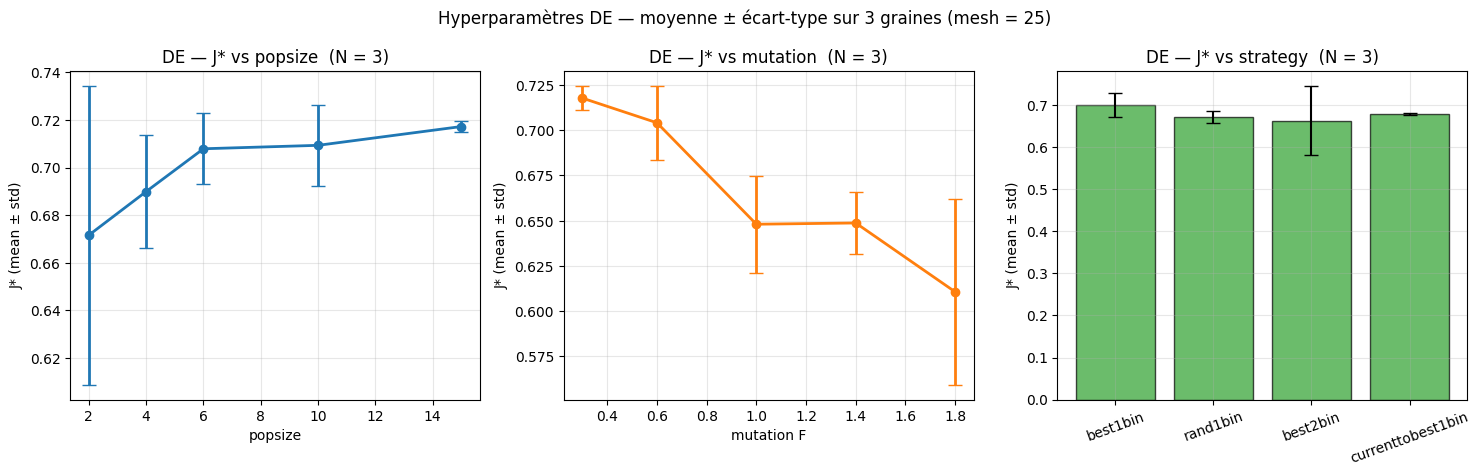

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].errorbar(df_de_ps['popsize'], df_de_ps['mean_J*'],
                  yerr=df_de_ps['std_J*'], fmt='o-', lw=2,
                  capsize=5, color='tab:blue')
axes[0].set_xlabel('popsize'); axes[0].set_ylabel('J* (mean ± std)')
axes[0].set_title(f'DE — J* vs popsize  (N = {N_SEEDS_HP})')

axes[1].errorbar(df_de_mut['mutation'], df_de_mut['mean_J*'],
                  yerr=df_de_mut['std_J*'], fmt='o-', lw=2,
                  capsize=5, color='tab:orange')
axes[1].set_xlabel('mutation F'); axes[1].set_ylabel('J* (mean ± std)')
axes[1].set_title(f'DE — J* vs mutation  (N = {N_SEEDS_HP})')

x = np.arange(len(df_de_strat))
axes[2].bar(x, df_de_strat['mean_J*'], yerr=df_de_strat['std_J*'],
             capsize=5, color='tab:green', alpha=0.7, edgecolor='black')
axes[2].set_xticks(x); axes[2].set_xticklabels(df_de_strat['strategy'], rotation=20)
axes[2].set_ylabel('J* (mean ± std)')
axes[2].set_title(f'DE — J* vs strategy  (N = {N_SEEDS_HP})')

fig.suptitle('Hyperparamètres DE — moyenne ± écart-type sur 3 graines (mesh = 25)')
fig.tight_layout()
fig.savefig(NB_DIR / 'etude5_DE_hyperparams.png', dpi=200, bbox_inches='tight')
plt.show()


## Étude 6 — Hyperparamètres BH (moyenne sur 3 graines)

Même approche : chaque valeur testée avec 3 graines.
Deux leviers étudiés :
- **`stepsize`** : amplitude des perturbations entre deux descentes locales ;
- **`T`** : température Metropolis pour accepter/rejeter les sauts.


### Helper : sweep BH


In [9]:
def bh_sweep(param_name, values, fixed=None):
    """Pour chaque valeur, lance N_SEEDS_HP runs BH et renvoie mean/std de J*."""
    fixed = fixed or {}
    rows = []
    for v in values:
        Js, n_evals, times = [], [], []
        for s in SEEDS_HP:
            kw = dict(niter=5, mesh_size=MESH_CHEAP, seed=s, **fixed)
            kw[param_name] = v
            r = run_basinhopping(BOUNDS, **kw)
            Js.append(r['best_J'])
            n_evals.append(r['n_eval'])
            times.append(r['time'])
            reset_optimization()
        rows.append({
            param_name : v,
            'mean_J*'  : np.mean(Js),
            'std_J*'   : np.std(Js, ddof=1) if len(Js) > 1 else 0.0,
            'min_J*'   : np.min(Js),
            'max_J*'   : np.max(Js),
            'mean_n_eval': np.mean(n_evals),
            'mean_time' : np.mean(times),
        })
        print(f'  {param_name} = {v}: J* = {np.mean(Js):.5f} ± {np.std(Js, ddof=1):.5f}'
              if len(Js) > 1 else
              f'  {param_name} = {v}: J* = {Js[0]:.5f}')
    return pd.DataFrame(rows)


### a) `stepsize`


In [10]:
STEPSIZES = [0.05, 0.15, 0.3, 0.6, 1.0]
df_bh_step = bh_sweep('stepsize', STEPSIZES)
df_bh_step.to_csv(NB_DIR / 'etude6_BH_stepsize.csv', index=False)
df_bh_step


  stepsize = 0.05: J* = 0.09027 ± 0.01064
  stepsize = 0.15: J* = 0.18236 ± 0.10031
  stepsize = 0.3: J* = 0.50709 ± 0.37140
  stepsize = 0.6: J* = 0.50810 ± 0.37229
  stepsize = 1.0: J* = 0.52251 ± 0.35048


,stepsize,mean_J*,std_J*,min_J*,max_J*,mean_n_eval,mean_time
0,0.05000,0.09027,0.01064,0.07823,0.09840,42.00000,3.77955
1,0.15000,0.18236,0.10031,0.07823,0.27834,42.00000,3.79999
2,0.30000,0.50709,0.37140,0.07823,0.72152,42.00000,3.77465
3,0.60000,0.50810,0.37229,0.07823,0.72598,42.00000,3.81171
4,1.00000,0.52251,0.35048,0.11787,0.73049,42.00000,3.80074


### b) `T` (température Metropolis)


In [11]:
TEMPS = [0.1, 0.5, 1.0, 3.0, 10.0]
df_bh_T = bh_sweep('T', TEMPS)
df_bh_T.to_csv(NB_DIR / 'etude6_BH_T.csv', index=False)
df_bh_T


  T = 0.1: J* = 0.51619 ± 0.35686
  T = 0.5: J* = 0.51619 ± 0.35686
  T = 1.0: J* = 0.50755 ± 0.37181
  T = 3.0: J* = 0.50755 ± 0.37181
  T = 10.0: J* = 0.50755 ± 0.37181


,T,mean_J*,std_J*,min_J*,max_J*,mean_n_eval,mean_time
0,0.10000,0.51619,0.35686,0.10413,0.72420,42.00000,3.81192
1,0.50000,0.51619,0.35686,0.10413,0.72420,42.00000,3.75387
2,1.00000,0.50755,0.37181,0.07823,0.72420,42.00000,3.72194
3,3.00000,0.50755,0.37181,0.07823,0.72420,42.00000,3.75749
4,10.00000,0.50755,0.37181,0.07823,0.72420,42.00000,3.74654


### Synthèse BH — moyenne ± écart-type


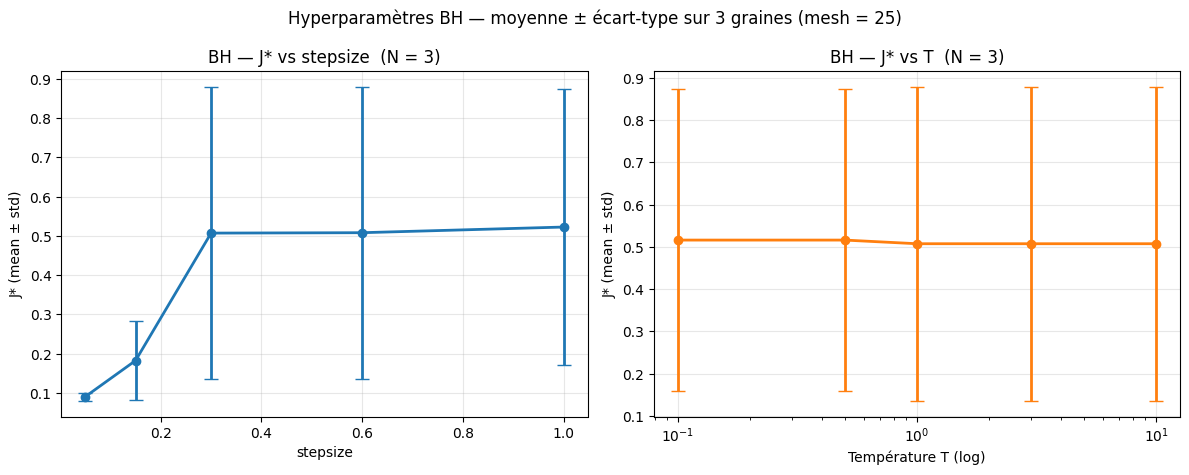

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].errorbar(df_bh_step['stepsize'], df_bh_step['mean_J*'],
                  yerr=df_bh_step['std_J*'], fmt='o-', lw=2,
                  capsize=5, color='tab:blue')
axes[0].set_xlabel('stepsize'); axes[0].set_ylabel('J* (mean ± std)')
axes[0].set_title(f'BH — J* vs stepsize  (N = {N_SEEDS_HP})')

axes[1].errorbar(df_bh_T['T'], df_bh_T['mean_J*'],
                  yerr=df_bh_T['std_J*'], fmt='o-', lw=2,
                  capsize=5, color='tab:orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Température T (log)'); axes[1].set_ylabel('J* (mean ± std)')
axes[1].set_title(f'BH — J* vs T  (N = {N_SEEDS_HP})')

fig.suptitle('Hyperparamètres BH — moyenne ± écart-type sur 3 graines (mesh = 25)')
fig.tight_layout()
fig.savefig(NB_DIR / 'etude6_BH_hyperparams.png', dpi=200, bbox_inches='tight')
plt.show()


## Étude 7 — Designs optimaux et champs de température

On reprend les meilleurs designs de l'Étude 1 (mesh = 50).


### Designs optimaux


In [13]:
designs = pd.DataFrame(
    {r['method']: list(r['best_x']) for r in results.values()},
    index=PARAM_LABELS,
).T
designs['J*'] = [r['best_J'] for r in results.values()]
designs.to_csv(NB_DIR / 'etude7_designs.csv')
designs


,k1,k2,k3,k4,k5,Bi,J*


/var/folders/1n/v6d5ys_s0fl57vsy1k975yzh0000gn/T/ipykernel_1416/2922287230.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


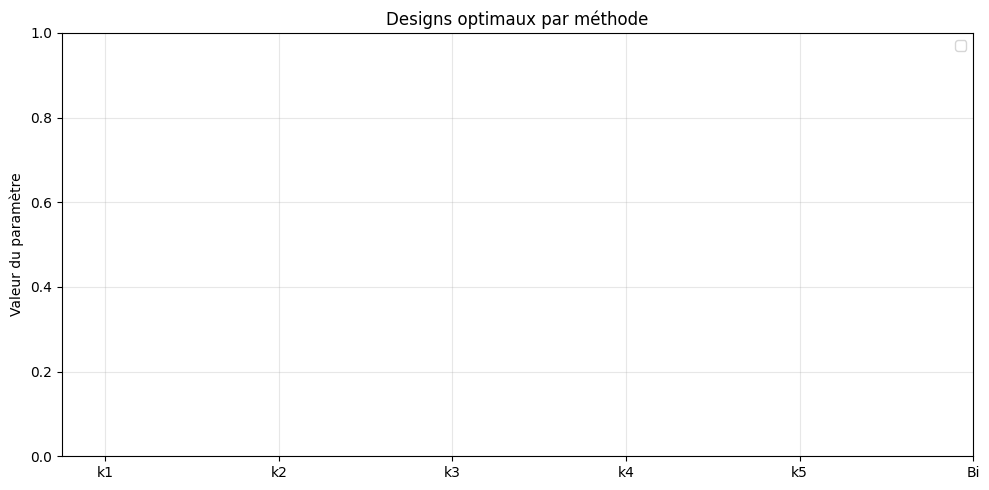

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(6); w = 0.25
for i, r in enumerate(results.values()):
    ax.bar(x + i * w, list(r['best_x']), w,
           label=r['method'], color=plt.cm.tab10.colors[i],
           edgecolor='black', linewidth=0.5)
ax.set_xticks(x + w); ax.set_xticklabels(PARAM_LABELS)
ax.set_ylabel('Valeur du paramètre')
ax.set_title('Designs optimaux par méthode')
ax.legend()
fig.tight_layout()
fig.savefig(NB_DIR / 'etude7_designs_bar.png', dpi=200, bbox_inches='tight')
plt.show()


### Champs $T$ des designs optimaux

Triangulation native du `.msh` pour respecter les vides entre ailettes.


TypeError: 'Axes' object is not iterable

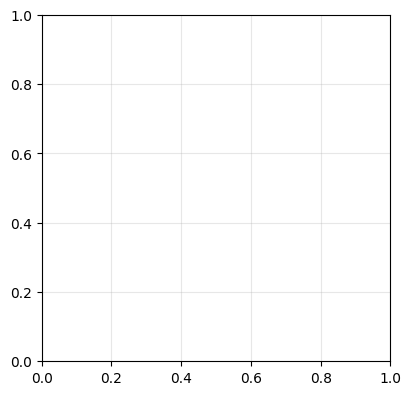

In [15]:
mesh_path = ensure_mesh(MESH_REF)
_, mesh_triangles, _ = read_freefem_mesh(mesh_path)

all_data = {}
T_init_path = NB_DIR / 'T_initial.dat'
run_solver(x0_ref, mesh_size=MESH_REF, t_out=str(T_init_path))
all_data['Initial (x = 0.5)'] = read_temperature_field(T_init_path)

for key, r in results.items():
    T_path = NB_DIR / f'T_{key}.dat'
    run_solver(list(r['best_x']), mesh_size=MESH_REF, t_out=str(T_path))
    all_data[r['method']] = read_temperature_field(T_path)

vmin = min(d[2].min() for d in all_data.values())
vmax = max(d[2].max() for d in all_data.values())

n = len(all_data)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
tcf = None
for ax, (name, (x, y, T)) in zip(axes, all_data.items()):
    tcf = draw_temperature(ax, x, y, T, triangles=mesh_triangles,
                            title=f'{name}\nT ∈ [{T.min():.3f}, {T.max():.3f}]',
                            vmin=vmin, vmax=vmax)
fig.colorbar(tcf, ax=axes, fraction=0.025, pad=0.04, label='T')
fig.suptitle('Champs T (échelle partagée)')
fig.savefig(NB_DIR / 'etude7_T_fields.png', dpi=200, bbox_inches='tight')
plt.show()


## Synthèse pour le rapport

À reformuler avec vos chiffres exacts.

### Étude 1 — Comparaison à budget équivalent
Quelle méthode atteint le plus haut $J^\star$, et à quel coût ? Le Pareto révèle-t-il
une dominance claire ?

### Étude 2 — Maillage
Mesh à partir duquel $J^\star$ se stabilise (mesh-independence). Croissance
attendue du temps total en $O(\text{mesh}^2)$.

### Études 3 et 4 — Robustesse
Comparer la variance de NM (sensibilité au $x_0$) à celle de DE/BH (sensibilité à
la graine). Si NM a une variance nettement plus grande, ça justifie le global.

### Étude 5 — Hyperparamètres DE
- **popsize** : y a-t-il un plateau ? Le gain marginal s'annule à partir de quelle valeur ?
- **mutation** : un optimum vers F = 0.7-1.0 ?
- **strategy** : `best1bin` (exploite) vs `rand1bin` (explore) — quel comportement observé ?

### Étude 6 — Hyperparamètres BH
- **stepsize** trop petit : un seul L-BFGS-B local, BH dégénère. Trop grand : random search.
- **T** : valeur 1.0 par défaut adaptée à l'échelle de variation de $J$ (≈ 0.5-1.0) ?

### Étude 7 — Designs optimaux
Les trois méthodes convergent-elles vers le même design ? Tendances physiques :
$k_i \to 1$ (haute conductivité), $\mathrm{Bi} \to 0.01$ (faible perte) ?
